Importando as bibliotecas e módulos necessários: 

In [1]:
import os
import pandas as pd
import numpy as np
import sys
import gc
import scipy.stats
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Importando as bases necessárias: 

In [2]:
df_2019 = pd.read_parquet(r"C:\Users\emill\Downloads\TCC\processed\Features_2019.parquet", engine="pyarrow")
df_2021 = pd.read_parquet(r"C:\Users\emill\Downloads\TCC\processed\Features_2021.parquet", engine="pyarrow")
df_2023 = pd.read_parquet(r"C:\Users\emill\Downloads\TCC\processed\Features_2023.parquet", engine="pyarrow")

### Modelagem Preditiva 
Esse código implementa modelos de Regressão Logística para prever se um aluno será Insuficiente ou Proficiente.

#### 2019

In [3]:
# Ajustando a variável alvo
df_2019['PROFICIENCIA_DESCRICAO'] = df_2019['PROFICIENCIA_DESCRICAO'].replace({
    'Básico': 'Insuficiente',
    'Avançado': 'Proficiente'
})

# Variável dependente
y = df_2019['PROFICIENCIA_DESCRICAO'].map({
    'Insuficiente': 0,
    'Proficiente': 1
})

# Variáveis independentes
X = df_2019.drop(columns=['PROFICIENCIA_DESCRICAO'])

# Cria dummies
X = pd.get_dummies(X, drop_first=True)

# Remove colunas constantes
X = X.loc[:, X.nunique() > 1]

# Remove valores ausentes
X = X.dropna()

# Ajusta y ao mesmo índice
y = y.loc[X.index]

# Converte para numérico
X = X.astype(float)
y = y.astype(int)

# Adiciona intercepto
X = sm.add_constant(X)

# Divide treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Modelo
log_reg = sm.Logit(y_train, X_train).fit()

#print(log_reg.summary())

Optimization terminated successfully.
         Current function value: 0.437510
         Iterations 7



Coeficientes, Odds Ratios e p-values do Modelo:
                                       Feature  Coefficient  Odds Ratio  \
16                    QTD_COMPUTADOR_3 ou mais     0.432350    1.540875   
15                       QTD_COMPUTADOR_1 ou 2     0.318794    1.375467   
38                      POS_EF_Somente estudar     0.306424    1.358558   
11                 ESCOL_MAE_Superior completo     0.294494    1.342447   
25              IDADE_INTROD_ESC_Não respondeu     0.268350    1.307805   
18                            QTD_CARRO_1 ou 2     0.214464    1.239198   
20                     QTD_CARRO_Não respondeu     0.187197    1.205864   
8                     ESCOL_MAE_Médio completo     0.161474    1.175242   
22                                 GARAGEM_Sim     0.146821    1.158146   
19                         QTD_CARRO_3 ou mais     0.097727    1.102661   
3                       COR_RACA_Não respondeu     0.031303    1.031798   
26                    REPROVACAO_Não respondeu     

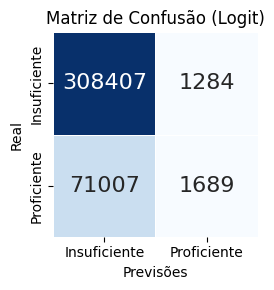

In [4]:
# Extraindo os coeficientes, odds ratios e p-values
coefficients = log_reg.params
odds_ratios = np.exp(coefficients)  # Odds ratios calculados como exp(coeficiente)
p_values = log_reg.pvalues

# Apresentando os resultados em um DataFrame
results = pd.DataFrame({
    'Feature': coefficients.index,
    'Coefficient': coefficients.values,
    'Odds Ratio': odds_ratios.values,
    'p-value': p_values.values
}).sort_values(by='Odds Ratio', ascending=False)

print("\nCoeficientes, Odds Ratios e p-values do Modelo:")
print(results)

# Previsões no conjunto de teste
y_pred = (log_reg.predict(X_test) > 0.5).astype(int)

# Avaliação do modelo
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAcurácia: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Insuficiente', 'Proficiente']))

# Gerando a matriz de confusão
conf_matrix = confusion_matrix(y_test, y_pred)

# Plotando a matriz de confusão com os nomes das classes
plt.figure(figsize=(5, 3))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False, square=True,
            annot_kws={"size": 16}, xticklabels=['Insuficiente', 'Proficiente'],
            yticklabels=['Insuficiente', 'Proficiente'], linewidths=0.5)

# Adicionando título e rótulos
plt.xlabel("Previsões")
plt.ylabel("Real")
plt.title("Matriz de Confusão (Logit)")
plt.tight_layout()
plt.show()

#### 2021

In [5]:
# Ajustando a variável alvo
df_2021['PROFICIENCIA_DESCRICAO'] = df_2021['PROFICIENCIA_DESCRICAO'].replace({
    'Básico': 'Insuficiente',
    'Avançado': 'Proficiente'
})

# Variável dependente
y = df_2021['PROFICIENCIA_DESCRICAO'].map({
    'Insuficiente': 0,
    'Proficiente': 1
})

# Variáveis independentes
X = df_2021.drop(columns=['PROFICIENCIA_DESCRICAO'])

# Cria dummies
X = pd.get_dummies(X, drop_first=True)

# Remove colunas constantes
X = X.loc[:, X.nunique() > 1]

# Remove valores ausentes
X = X.dropna()

# Ajusta y ao mesmo índice
y = y.loc[X.index]

# Converte para numérico
X = X.astype(float)
y = y.astype(int)

# Adiciona intercepto
X = sm.add_constant(X)

# Divide treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Modelo
log_reg = sm.Logit(y_train, X_train).fit()

#print(log_reg.summary())

Optimization terminated successfully.
         Current function value: 0.388532
         Iterations 7



Coeficientes, Odds Ratios e p-values do Modelo:
                                       Feature  Coefficient  Odds Ratio  \
2                               SEXO_Masculino     0.639736    1.895981   
18                    QTD_COMPUTADOR_3 ou mais     0.513233    1.670684   
17                       QTD_COMPUTADOR_1 ou 2     0.372205    1.450931   
13                 ESCOL_MAE_Superior completo     0.345678    1.412948   
3                           SEXO_Não respondeu     0.269723    1.309602   
40                      POS_EF_Somente estudar     0.212846    1.237195   
10                    ESCOL_MAE_Médio completo     0.207439    1.230522   
20                            QTD_CARRO_1 ou 2     0.206634    1.229533   
27              IDADE_INTROD_ESC_Não respondeu     0.201284    1.222972   
23                       GARAGEM_Não respondeu     0.193045    1.212937   
24                                 GARAGEM_Sim     0.112312    1.118862   
28                    REPROVACAO_Não respondeu     

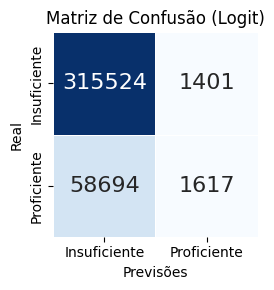

In [6]:
# Extraindo os coeficientes, odds ratios e p-values
coefficients = log_reg.params
odds_ratios = np.exp(coefficients)  # Odds ratios calculados como exp(coeficiente)
p_values = log_reg.pvalues

# Apresentando os resultados em um DataFrame
results = pd.DataFrame({
    'Feature': coefficients.index,
    'Coefficient': coefficients.values,
    'Odds Ratio': odds_ratios.values,
    'p-value': p_values.values
}).sort_values(by='Odds Ratio', ascending=False)

print("\nCoeficientes, Odds Ratios e p-values do Modelo:")
print(results)

# Previsões no conjunto de teste
y_pred = (log_reg.predict(X_test) > 0.5).astype(int)

# Avaliação do modelo
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAcurácia: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Insuficiente', 'Proficiente']))

# Gerando a matriz de confusão
conf_matrix = confusion_matrix(y_test, y_pred)

# Plotando a matriz de confusão com os nomes das classes
plt.figure(figsize=(5, 3))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False, square=True,
            annot_kws={"size": 16}, xticklabels=['Insuficiente', 'Proficiente'],
            yticklabels=['Insuficiente', 'Proficiente'], linewidths=0.5)

# Adicionando título e rótulos
plt.xlabel("Previsões")
plt.ylabel("Real")
plt.title("Matriz de Confusão (Logit)")
plt.tight_layout()
plt.show()

#### 2023

In [7]:
# Ajustando a variável alvo
df_2023['PROFICIENCIA_DESCRICAO'] = df_2023['PROFICIENCIA_DESCRICAO'].replace({
    'Básico': 'Insuficiente',
    'Avançado': 'Proficiente'
})

# Variável dependente
y = df_2023['PROFICIENCIA_DESCRICAO'].map({
    'Insuficiente': 0,
    'Proficiente': 1
})

# Variáveis independentes
X = df_2023.drop(columns=['PROFICIENCIA_DESCRICAO'])

# Cria dummies
X = pd.get_dummies(X, drop_first=True)

# Remove colunas constantes
X = X.loc[:, X.nunique() > 1]

# Remove valores ausentes
X = X.dropna()

# Ajusta y ao mesmo índice
y = y.loc[X.index]

# Converte para numérico
X = X.astype(float)
y = y.astype(int)

# Adiciona intercepto
X = sm.add_constant(X)

# Divide treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Modelo
log_reg = sm.Logit(y_train, X_train).fit()

#print(log_reg.summary())

Optimization terminated successfully.
         Current function value: 0.406694
         Iterations 7



Coeficientes, Odds Ratios e p-values do Modelo:
                                       Feature  Coefficient  Odds Ratio  \
2                               SEXO_Masculino     0.626337    1.870746   
4                           SEXO_Não respondeu     0.604319    1.830005   
19                    QTD_COMPUTADOR_3 ou mais     0.504289    1.655808   
14                 ESCOL_MAE_Superior completo     0.353319    1.423785   
18                       QTD_COMPUTADOR_1 ou 2     0.325491    1.384711   
3                       SEXO_Não quis declarar     0.283505    1.327775   
41                      POS_EF_Somente estudar     0.250879    1.285155   
11                    ESCOL_MAE_Médio completo     0.224677    1.251918   
24                       GARAGEM_Não respondeu     0.215420    1.240383   
21                            QTD_CARRO_1 ou 2     0.191992    1.211661   
28              IDADE_INTROD_ESC_Não respondeu     0.152471    1.164709   
31                TEMPO_ESTUDO_Mais de 2 horas     

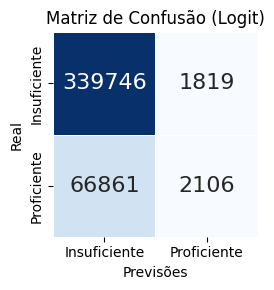

In [8]:
# Extraindo os coeficientes, odds ratios e p-values
coefficients = log_reg.params
odds_ratios = np.exp(coefficients)  # Odds ratios calculados como exp(coeficiente)
p_values = log_reg.pvalues

# Apresentando os resultados em um DataFrame
results = pd.DataFrame({
    'Feature': coefficients.index,
    'Coefficient': coefficients.values,
    'Odds Ratio': odds_ratios.values,
    'p-value': p_values.values
}).sort_values(by='Odds Ratio', ascending=False)

print("\nCoeficientes, Odds Ratios e p-values do Modelo:")
print(results)

# Previsões no conjunto de teste
y_pred = (log_reg.predict(X_test) > 0.5).astype(int)

# Avaliação do modelo
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAcurácia: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Insuficiente', 'Proficiente']))

# Gerando a matriz de confusão
conf_matrix = confusion_matrix(y_test, y_pred)

# Plotando a matriz de confusão com os nomes das classes
plt.figure(figsize=(5, 3))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False, square=True,
            annot_kws={"size": 16}, xticklabels=['Insuficiente', 'Proficiente'],
            yticklabels=['Insuficiente', 'Proficiente'], linewidths=0.5)

# Adicionando título e rótulos
plt.xlabel("Previsões")
plt.ylabel("Real")
plt.title("Matriz de Confusão (Logit)")
plt.tight_layout()
plt.show()